# Prediksi Churn Pelanggan Telekomunikasi

**Penulis:** Iqbal Ryuka — Program Studi Sains Data, Fakultas Ilmu Komputer dan Teknologi Informasi, Universitas Muhammadiyah Sumatera Utara

## Latar Belakang
*Churn* adalah kondisi ketika pelanggan berhenti berlangganan. Mempertahankan pelanggan lama umumnya jauh lebih murah daripada mendapatkan pelanggan baru, sehingga perusahaan perlu **mengidentifikasi pelanggan yang berisiko churn lebih awal** agar dapat diberi program retensi.

## Tujuan
1. Memahami karakteristik pelanggan yang melakukan churn melalui *Exploratory Data Analysis* (EDA).
2. Membangun dan membandingkan model klasifikasi untuk memprediksi churn.
3. Menentukan faktor yang paling berpengaruh dan memberi rekomendasi bisnis.

## Dataset
[IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) — 7.043 pelanggan, 21 kolom (demografi, layanan yang digunakan, informasi akun, dan label `Churn`).

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_prep import load_raw, load_clean, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
FIG = "../reports/figures/"


## 1. Memahami Data

In [2]:
raw = load_raw()
print("Ukuran data:", raw.shape)
raw.head()

Ukuran data: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges bertipe object -> cek nilai yang tidak bisa dikonversi ke angka
tc = pd.to_numeric(raw["TotalCharges"], errors="coerce")
raw.loc[tc.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Terdapat **11 baris** dengan `TotalCharges` kosong, dan semuanya memiliki `tenure = 0` (pelanggan baru yang belum pernah ditagih). Karena itu nilainya diisi **0**, bukan dihapus.

Langkah pembersihan di `src/data_prep.py`:
- konversi `TotalCharges` ke numerik dan isi nilai kosong dengan 0,
- ubah `SeniorCitizen` (0/1) menjadi kategori Yes/No,
- ubah target `Churn` menjadi 0/1,
- tambah fitur turunan `AvgChargePerMonth` dan `TenureGroup`,
- hapus `customerID` karena hanya identitas.

In [5]:
df = load_clean()
print("Ukuran setelah dibersihkan:", df.shape)
print("Jumlah missing value:", df.isna().sum().sum())
print("Jumlah baris duplikat:", df.duplicated().sum())
df.describe().round(2)

Ukuran setelah dibersihkan: (7043, 22)
Jumlah missing value: 0
Jumlah baris duplikat: 22


,tenure,MonthlyCharges,TotalCharges,Churn,AvgChargePerMonth
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,0.27,64.70
std,24.56,30.09,2266.79,0.44,30.27
min,0.00,18.25,0.00,0.00,0.00
25%,9.00,35.50,398.55,0.00,35.65
50%,29.00,70.35,1394.55,0.00,70.30
75%,55.00,89.85,3786.60,1.00,90.17
max,72.00,118.75,8684.80,1.00,121.40


Baris duplikat yang muncul adalah pelanggan **berbeda** (customerID berbeda) yang kebetulan memiliki atribut identik setelah `customerID` dihapus, sehingga **tetap dipertahankan**.

## 2. Exploratory Data Analysis

### 2.1 Distribusi Target

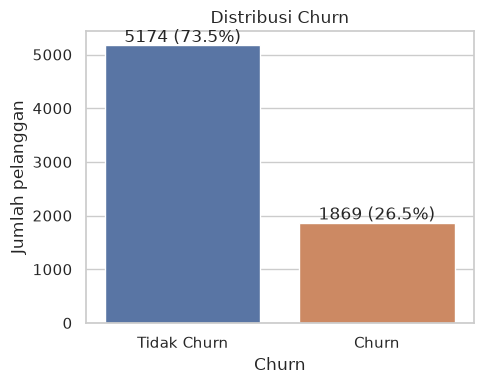

In [6]:
counts = df[TARGET].value_counts().rename({0: "Tidak Churn", 1: "Churn"})
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 60, f"{v} ({v / counts.sum():.1%})", ha="center")
ax.set_ylabel("Jumlah pelanggan"); ax.set_title("Distribusi Churn")
plt.tight_layout(); plt.savefig(FIG + "distribusi_churn.png", dpi=120); plt.show()

Data **tidak seimbang** (±26,5% churn). Karena itu evaluasi tidak cukup memakai akurasi saja — digunakan juga **ROC-AUC, recall, precision, dan F1**.

### 2.2 Fitur Numerik terhadap Churn

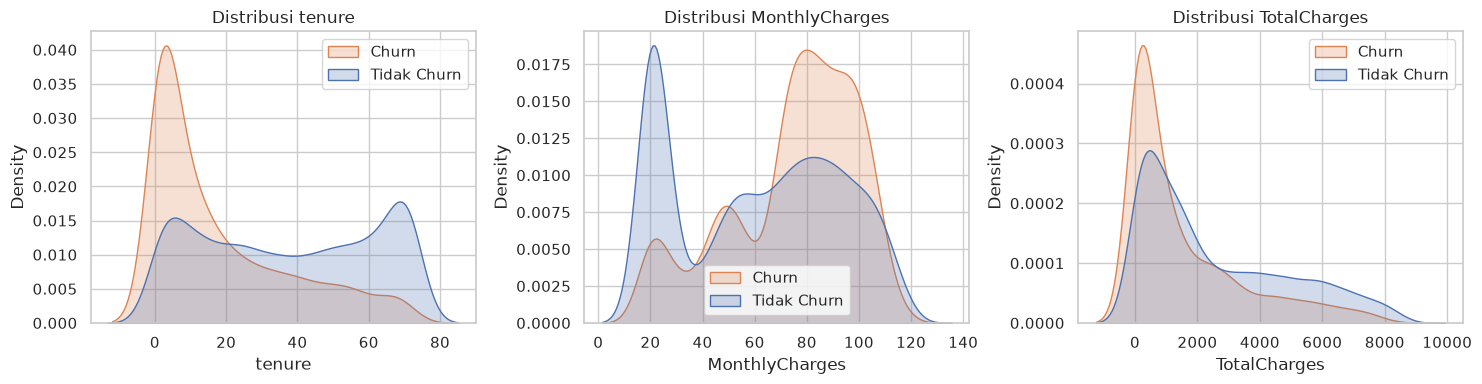

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True,
                palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(f"Distribusi {col}")
    ax.legend(["Churn", "Tidak Churn"])
plt.tight_layout(); plt.savefig(FIG + "distribusi_numerik.png", dpi=120); plt.show()

In [8]:
df.groupby(TARGET)[["tenure", "MonthlyCharges", "TotalCharges"]].median().rename(index={0: "Tidak Churn", 1: "Churn"}).round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
Tidak Churn,38.0,64.43,1679.52
Churn,10.0,79.65,703.55


**Temuan:**
- Pelanggan yang churn umumnya memiliki **tenure pendek** (median jauh lebih rendah) — risiko churn tertinggi ada di bulan-bulan awal berlangganan.
- Pelanggan churn cenderung memiliki **tagihan bulanan lebih tinggi**.

### 2.3 Tingkat Churn per Kategori

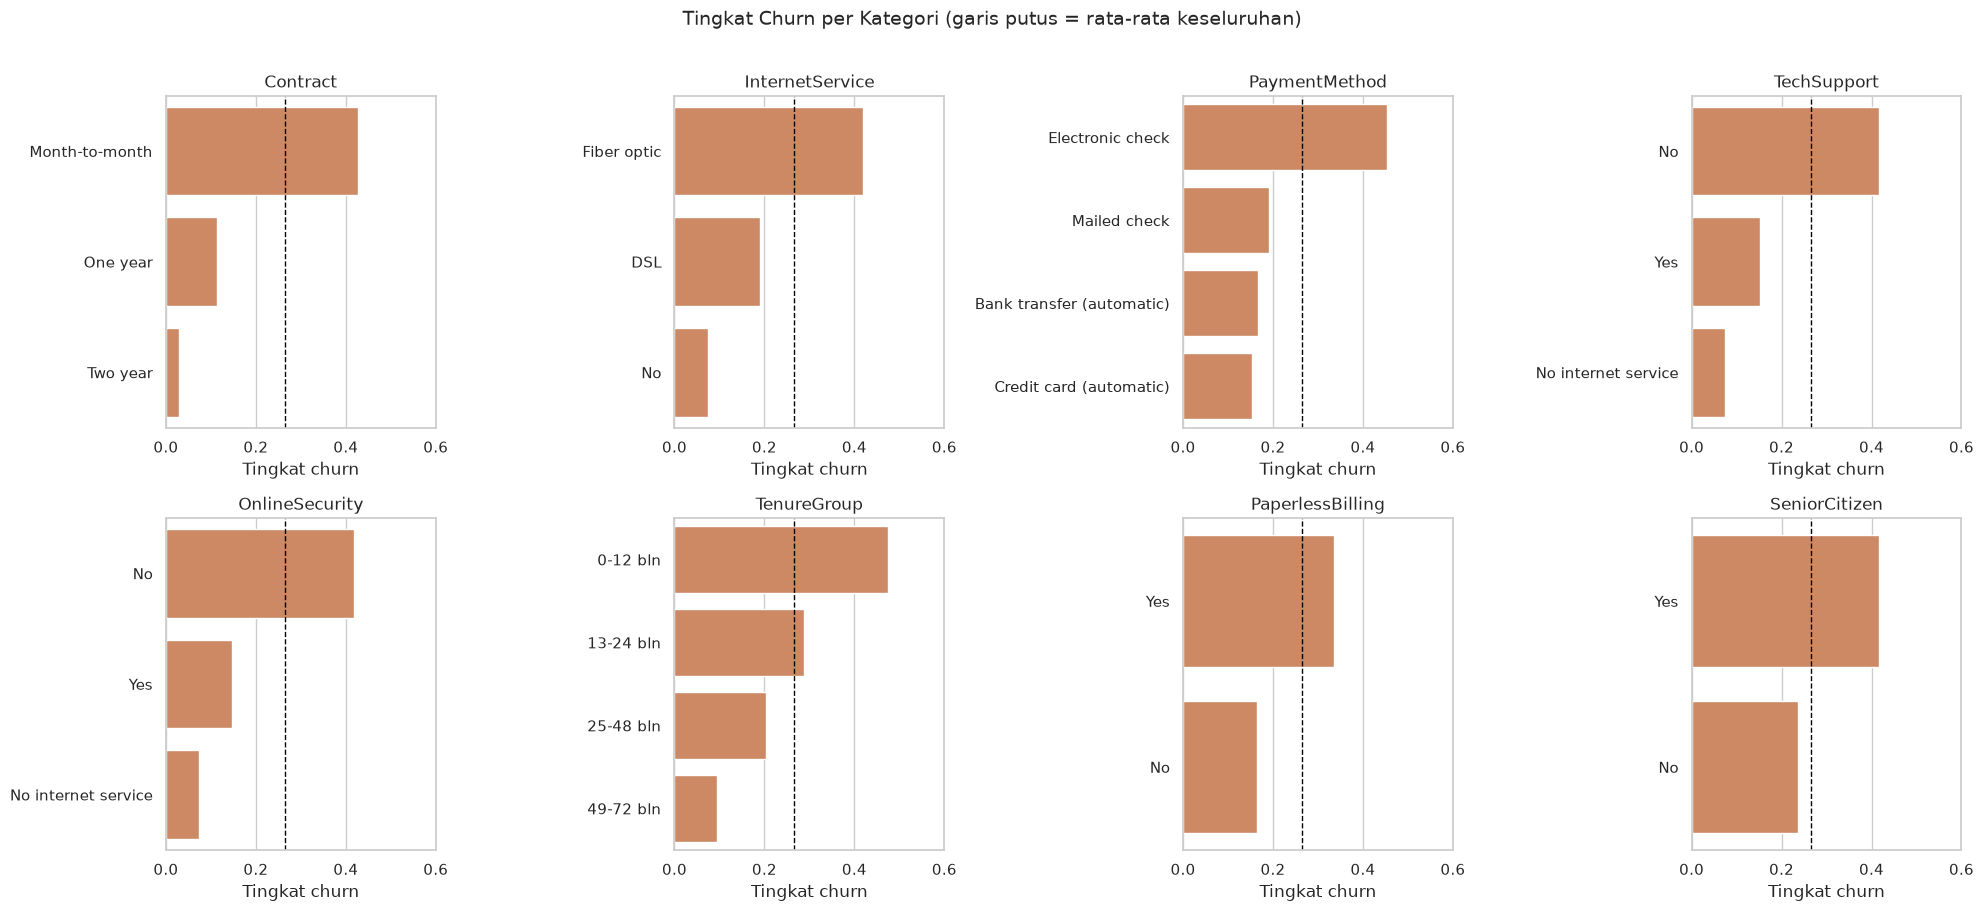

In [9]:
cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
        "OnlineSecurity", "TenureGroup", "PaperlessBilling", "SeniorCitizen"]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.ravel(), cols):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), color="#DD8452", ax=ax)
    ax.axvline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Tingkat churn"); ax.set_ylabel(""); ax.set_title(col)
    ax.set_xlim(0, 0.6)
plt.suptitle("Tingkat Churn per Kategori (garis putus = rata-rata keseluruhan)", y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig(FIG + "churn_per_kategori.png", dpi=120, bbox_inches="tight"); plt.show()

In [10]:
pd.crosstab(df["Contract"], df[TARGET], normalize="index").rename(columns={0: "Tidak Churn", 1: "Churn"}).round(3)

Churn,Tidak Churn,Churn
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


**Temuan:**
- **Kontrak bulanan (Month-to-month)** memiliki tingkat churn jauh lebih tinggi dibanding kontrak 1 atau 2 tahun.
- Pelanggan **Fiber optic** lebih sering churn dibanding DSL.
- Metode pembayaran **Electronic check** memiliki tingkat churn tertinggi.
- Pelanggan **tanpa Tech Support / Online Security** lebih rentan churn.
- Pelanggan **lansia (SeniorCitizen)** dan pengguna **paperless billing** juga lebih rentan.

### 2.4 Korelasi Fitur Numerik

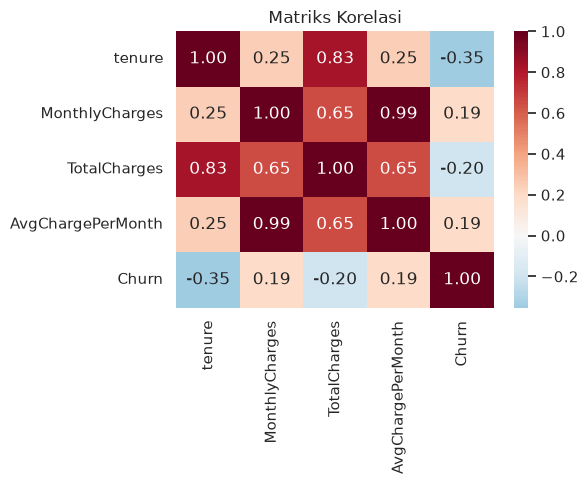

In [11]:
corr = df[NUMERIC_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Matriks Korelasi")
plt.tight_layout(); plt.savefig(FIG + "korelasi.png", dpi=120); plt.show()

`TotalCharges` sangat berkorelasi dengan `tenure` (wajar, karena total = bulanan × lama berlangganan). Model berbasis pohon tidak terganggu oleh hal ini, sedangkan pada regresi logistik efeknya hanya pada interpretasi koefisien.

## 3. Pemodelan

Pipeline (`src/train.py`):
- **Pra-pemrosesan:** `StandardScaler` untuk fitur numerik, `OneHotEncoder` untuk fitur kategorik (di dalam `Pipeline` agar tidak terjadi *data leakage*).
- **Pembagian data:** 80% latih / 20% uji, *stratified*.
- **Model:** Logistic Regression, Random Forest, Gradient Boosting.
- **Validasi:** 5-fold *Stratified Cross-Validation* pada data latih.

In [12]:
from train import split, cross_validate_models, fit_all, test_metrics

X_train, X_test, y_train, y_test = split(df)
print("Latih:", X_train.shape, " Uji:", X_test.shape)

cv_table = cross_validate_models(X_train, y_train)
cv_table.round(4)

Latih: (5634, 21)  Uji: (1409, 21)


,Model,ROC-AUC,ROC-AUC (std),F1,Recall,Precision
0,Gradient Boosting,0.8477,0.0111,0.5833,0.5224,0.6612
1,Logistic Regression,0.8458,0.0113,0.6275,0.7960,0.5181
2,Random Forest,0.8456,0.0096,0.6313,0.7652,0.5374


In [13]:
fitted = fit_all(X_train, y_train)
test_table = pd.DataFrame({name: test_metrics(p, X_test, y_test) for name, p in fitted.items()}).T
test_table.round(4)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7331,0.4983,0.7914,0.6116,0.8421
Random Forest,0.7615,0.5349,0.7781,0.6340,0.8418
Gradient Boosting,0.8041,0.6738,0.5080,0.5793,0.8432


In [14]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
ax.set_title("Kurva ROC pada Data Uji")
plt.tight_layout(); plt.show()

Ketiga model memiliki ROC-AUC yang hampir sama (±0,84). Perbedaannya ada pada *trade-off* precision–recall di threshold 0,5:
- **Gradient Boosting**: akurasi & precision tertinggi, tetapi recall rendah (banyak pelanggan churn terlewat).
- **Logistic Regression / Random Forest** (dengan `class_weight="balanced"`): recall jauh lebih tinggi.

Dalam kasus churn, **melewatkan pelanggan yang akan churn (false negative) biasanya lebih mahal** daripada memberi promo ke pelanggan yang sebenarnya tidak churn. Karena itu threshold perlu disesuaikan.

## 4. Penyesuaian Threshold

In [15]:
from sklearn.metrics import precision_recall_curve, f1_score

best_name = cv_table.loc[0, "Model"]
best = fitted[best_name]
proba = best.predict_proba(X_test)[:, 1]

prec, rec, thr = precision_recall_curve(y_test, proba)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.argmax(f1[:-1])
best_thr = thr[best_idx]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr, prec[:-1], label="Precision")
ax.plot(thr, rec[:-1], label="Recall")
ax.plot(thr, f1[:-1], label="F1")
ax.axvline(best_thr, color="black", linestyle="--", linewidth=1, label=f"Threshold optimal F1 = {best_thr:.2f}")
ax.set_xlabel("Threshold"); ax.set_title(f"Precision / Recall vs Threshold - {best_name}")
ax.legend()
plt.tight_layout(); plt.savefig(FIG + "threshold.png", dpi=120); plt.show()

print(f"Model: {best_name}")
print(f"Threshold 0.50 -> F1 = {f1_score(y_test, proba >= 0.5):.4f}")
print(f"Threshold {best_thr:.2f} -> F1 = {f1_score(y_test, proba >= best_thr):.4f}")

Model: Gradient Boosting
Threshold 0.50 -> F1 = 0.5793
Threshold 0.34 -> F1 = 0.6348


> Catatan metodologi: threshold di sini dipilih langsung pada data uji untuk tujuan ilustrasi. Pada penerapan nyata, threshold sebaiknya dipilih menggunakan data validasi terpisah (atau prediksi *out-of-fold*) agar estimasi performa tetap jujur.

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t in zip(axes, [0.5, best_thr]):
    ConfusionMatrixDisplay.from_predictions(y_test, (proba >= t).astype(int),
        display_labels=["Tidak Churn", "Churn"], cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Threshold = {t:.2f}")
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba >= best_thr).astype(int), target_names=["Tidak Churn", "Churn"]))

              precision    recall  f1-score   support

 Tidak Churn       0.89      0.80      0.84      1035
       Churn       0.56      0.73      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



## 5. Faktor yang Paling Berpengaruh

In [17]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best, X_test, y_test, scoring="roc_auc",
                                n_repeats=10, random_state=42, n_jobs=-1)
imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=imp.head(12).values, y=imp.head(12).index, color="#4C72B0", ax=ax)
ax.set_xlabel("Penurunan ROC-AUC saat fitur diacak"); ax.set_ylabel("")
ax.set_title("Permutation Importance")
plt.tight_layout(); plt.show()
imp.head(10).round(4)

Contract             0.0803
tenure               0.0423
MonthlyCharges       0.0095
InternetService      0.0087
TotalCharges         0.0084
AvgChargePerMonth    0.0063
OnlineSecurity       0.0063
TechSupport          0.0055
PaymentMethod        0.0030
MultipleLines        0.0024
dtype: float64

*Permutation importance* mengukur seberapa besar performa model turun ketika nilai sebuah fitur diacak. Hasilnya konsisten dengan EDA: **jenis kontrak, tenure, jenis layanan internet, dan biaya** adalah penentu utama churn.

## 6. Kesimpulan & Rekomendasi

**Kesimpulan**
- Sekitar **26,5%** pelanggan melakukan churn.
- Model terbaik mencapai **ROC-AUC ±0,84** pada data uji; ketiga model yang diuji memberi hasil yang sebanding.
- Dengan penyesuaian threshold, model dapat menangkap sebagian besar pelanggan yang akan churn dengan *precision* yang masih wajar.

**Rekomendasi bisnis**
1. **Dorong migrasi ke kontrak jangka panjang** — misalnya diskon untuk pelanggan bulanan yang beralih ke kontrak 1 atau 2 tahun.
2. **Fokus retensi pada 12 bulan pertama** — program *onboarding*, pengecekan kepuasan, dan promo awal.
3. **Evaluasi layanan Fiber optic** — tingginya churn bisa menandakan masalah harga atau kualitas layanan.
4. **Tawarkan bundel Tech Support & Online Security** — pelanggan yang memakai layanan ini lebih loyal.
5. **Dorong pembayaran otomatis** (transfer bank/kartu kredit) sebagai pengganti *electronic check*.

**Pengembangan lanjutan**
- *Hyperparameter tuning* (GridSearchCV / Optuna) dan mencoba XGBoost / LightGBM.
- Pemilihan threshold berbasis biaya (*cost-sensitive*) menggunakan estimasi biaya retensi vs kehilangan pelanggan.
- Interpretasi per pelanggan dengan SHAP.
- *Deployment* sederhana dengan Streamlit.